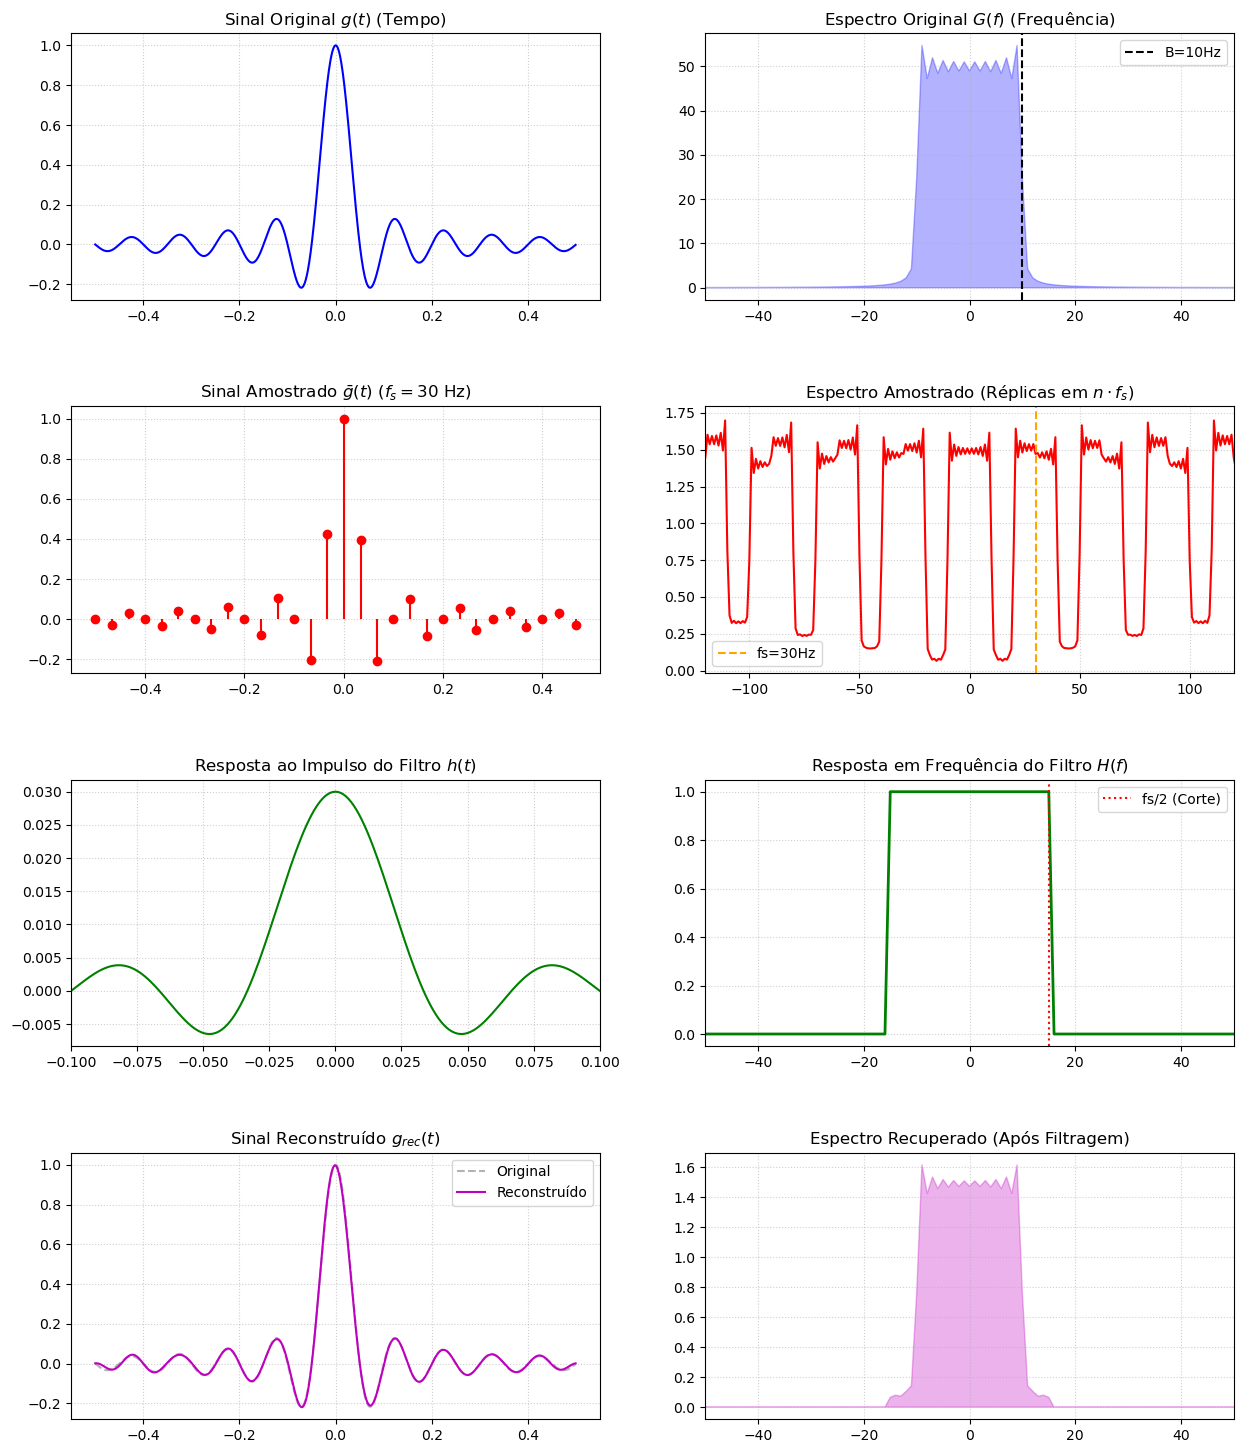

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq

# --- 1. CONFIGURAÇÕES ---
B = 10                  # Banda do sinal (Hz)
fs = 30                 # Frequência de amostragem (fs > 2B)
Ts = 1/fs
fs_sim = 1000           # Frequência de simulação "analógica"
t = np.linspace(-0.5, 0.5, int(fs_sim), endpoint=False)

# --- 2. SINAL ORIGINAL ---
g_t = np.sinc(2 * B * t)

# --- 3. SINAL AMOSTRADO ---
g_sampled_t = np.zeros_like(t)
indices = np.searchsorted(t, np.arange(min(t), max(t), Ts))
g_sampled_t[indices] = g_t[indices]

# --- 4. FILTRO DE RECONSTRUÇÃO (H) ---
xf = fftshift(fftfreq(len(t), 1/fs_sim))
H_f = np.where(np.abs(xf) <= fs/2, 1, 0) 
h_t = (fs/fs_sim) * np.sinc(fs * t)

# --- 5. RECONSTRUÇÃO (Matemática estável) ---
G_sampled_f = fftshift(fft(g_sampled_t))
G_rec_f = G_sampled_f * H_f
g_rec_t = np.real(np.fft.ifft(np.fft.ifftshift(G_rec_f)))

# --- 6. VISUALIZAÇÃO ---
fig, axs = plt.subplots(4, 2, figsize=(15, 18))
plt.subplots_adjust(hspace=0.4)

# A. SINAL ORIGINAL
axs[0, 0].plot(t, g_t, 'b')
axs[0, 0].set_title("Sinal Original $g(t)$ (Tempo)")
axs[0, 1].fill_between(xf, 0, np.abs(fftshift(fft(g_t))), color='b', alpha=0.3)
axs[0, 1].axvline(B, color='black', linestyle='--', label=f'B={B}Hz') # Indicação de B
axs[0, 1].set_title("Espectro Original $G(f)$ (Frequência)")
axs[0, 1].set_xlim(-50, 50)
axs[0, 1].legend()

# B. SINAL AMOSTRADO
axs[1, 0].stem(t[indices], g_t[indices], 'r', markerfmt='ro', basefmt=" ")
axs[1, 0].set_title(f"Sinal Amostrado $\\bar{{g}}(t)$ ($f_s = {fs}$ Hz)")
axs[1, 1].plot(xf, np.abs(G_sampled_f), 'r')
axs[1, 1].axvline(fs, color='orange', linestyle='--', label=f'fs={fs}Hz') # Indicação de fs
axs[1, 1].set_title("Espectro Amostrado (Réplicas em $n \\cdot f_s$)")
axs[1, 1].set_xlim(-120, 120)
axs[1, 1].legend()

# C. FILTRO DE RECONSTRUÇÃO
axs[2, 0].plot(t, h_t, 'g')
axs[2, 0].set_title("Resposta ao Impulso do Filtro $h(t)$")
axs[2, 0].set_xlim(-0.1, 0.1)
axs[2, 1].plot(xf, H_f, 'g', lw=2)
axs[2, 1].axvline(fs/2, color='red', linestyle=':', label='fs/2 (Corte)') # Indicação de fs/2
axs[2, 1].set_title("Resposta em Frequência do Filtro $H(f)$")
axs[2, 1].set_xlim(-50, 50)
axs[2, 1].legend()

# D. SINAL RECONSTRUÍDO (Recuperado com escala correta)
axs[3, 0].plot(t, g_t, 'k--', alpha=0.3, label="Original")
axs[3, 0].plot(t, g_rec_t * (fs_sim/fs), 'm', label="Reconstruído") 
axs[3, 0].set_title("Sinal Reconstruído $g_{rec}(t)$")
axs[3, 0].legend()
axs[3, 1].fill_between(xf, 0, np.abs(G_rec_f), color='m', alpha=0.3)
axs[3, 1].set_title("Espectro Recuperado (Após Filtragem)")
axs[3, 1].set_xlim(-50, 50)

for ax in axs.flat:
    ax.grid(True, linestyle=':', alpha=0.6)

plt.show()